In [1]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: /data6/yuzihan/WorkSpace/35-HuaweiCrowdSimulation/HuaweiCrowdSimulationCode


In [ ]:
from argparse import Namespace
from src.dataset import SDDDataset
from src.utils.logger import init_logger

init_logger('src')

args = Namespace(
    hist_step=8, pred_step=1, skip_step=1, roll_step=12, 
    fps=2.5, dot_per_meter=5, seed=2830, 
    debug=False, 
    cache_dataset=False, 
)

In [5]:
import os
import sys
import torch
import logging
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from src.utils.homography import calc_homography_mat, affine_transformation, image_to_world
from src.dataset.sdd_dataset import SDDDataset

data_path = Path('data/SDD/annotations/bookstore/video0/annotations.txt')

## 读取数据
df_data = pd.read_csv(
    data_path,
    sep=" ",
    names=[
        "id", "xmin", "ymin", "xmax", "ymax",
        "frame", "lost", "occluded", "generated", "label",
    ],
    usecols=["id", "xmin", "ymin", "xmax", "ymax", "frame", "label"],
)
df_data["x"] = (df_data["xmin"] + df_data["xmax"]) / 2
df_data["y"] = (df_data["ymin"] + df_data["ymax"]) / 2
df_data = df_data.rename(columns={"frame": "f", "label": "type"})
df_data['type'] = df_data['type'].replace({
    'Pedestrian': 'pedestrian',
    'Skater': 'vehicle',
    'Biker': 'vehicle',
    'Cart': 'vehicle',
    'Car': 'vehicle',
    'Bus': 'vehicle',
})
df_data = df_data[['f', 'id', 'x', 'y', 'type']]  # 第一维向右，第二维向下

## 仿射变换
H = SDDDataset.get_homography_mat(data_path=data_path)
df_data[['x', 'y']] = affine_transformation(df_data[['x', 'y']].values, H)

## 数据重采样
df_data = SDDDataset.resample_dataframe(df_data, raw_fps=SDDDataset.raw_fps, target_fps=args.fps)

## 读取地图
map_path = data_path.parent / f"map.png"
if map_path.exists():
    image = np.array(Image.open(map_path).convert('L'))  # (H, W)  第一维向下，第二维向右
    image_ = image.T # 转置，使得第一维向右，第二维向下，与 df_data 中的坐标系对齐
    map, xmin, xmax, ymin, ymax = image_to_world(image_, H, dot_per_meter=5)  # 第一维向右，第二维向上，即 xy 坐标
else:
    dot_per_meter = args.dot_per_meter
    xmin, xmax = df_data['x'].min(), df_data['x'].max()
    ymin, ymax = df_data['y'].min(), df_data['y'].max()
    len_x = len(np.arange(xmin, xmax+1/dot_per_meter, 1/dot_per_meter)[:-1])
    len_y = len(np.arange(ymin, ymax+1/dot_per_meter, 1/dot_per_meter)[:-1])
    map = np.full((len_x, len_y), np.nan)
map

array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,   0.,   0., ..., 255., 255., 255.],
       [ nan,   0.,   0., ..., 255., 255., 255.],
       ...,
       [ nan,   0.,   0., ..., 255., 255., 255.],
       [ nan,   0.,   0., ..., 255., 255., 255.],
       [ nan,   0.,   0., ..., 255., 255., 255.]], shape=(182, 238))

In [6]:
xmin, xmax, ymin, ymax

(np.float64(9.218598108835423e-15),
 np.float64(47.433333333332754),
 np.float64(0.03333333333055533),
 np.float64(36.266666666668286))

<Axes: ylabel='speed'>

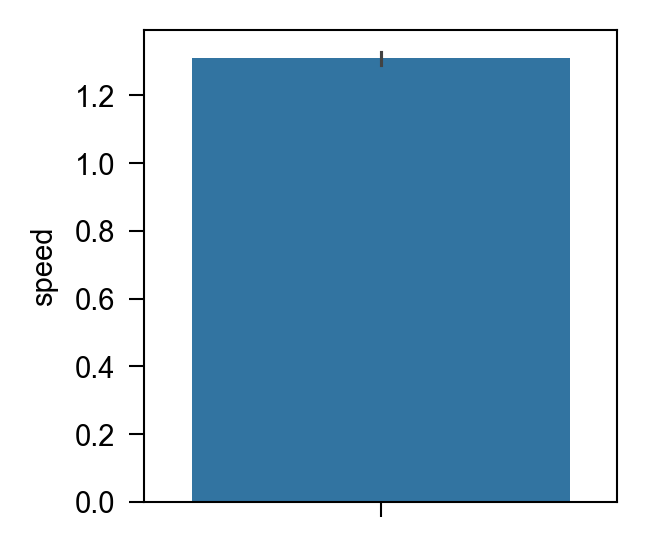

In [11]:
import seaborn as sns
from src.utils.plot import get_fig

for pid, group in df_data.groupby('id'):
    speed = group[['x', 'y']].diff().pow(2).sum(axis=1).pow(0.5) / group['f'].diff() * 2.5  # (m/s)
    df_data.loc[group.index, 'speed'] = speed

fi, fig, axes = get_fig(1, 1, AW=4, AH=4, dpi=300, sharex=True, sharey=True)
sns.barplot(data=df_data[df_data['speed']>0], y='speed', ax=axes[0])

In [12]:
from tqdm import tqdm

args.cache_dataset = False
datasets = SDDDataset.load_data_batch(args, './data/SDD')

speeds = {}
for dataset in tqdm(datasets):
    df_data = dataset.df_data.copy()
    df_data = df_data[df_data['type'] == 'pedestrian']
    df_data = df_data.sort_values(['id', 'f'])
    for pid, group in df_data.groupby('id'):
        speed = group[['x', 'y']].diff().pow(2).sum(axis=1).pow(0.5) / group['f'].diff() * 2.5  # (m/s)
        df_data.loc[group.index, 'speed'] = speed
    speeds[dataset.name] = df_data
speeds

[None|sdd_dataset|I|Oct10 21:25:03|0:05:25.748597] Caching dataset-list to data/.cache/SDD.pkl
Loading SDD datasets:   0%|          | 0/60 [00:00<?, ?it/s, bookstore/video0]

[None|base_dataset|I|Oct10 21:25:43|0:06:06.222229] Normalized x with mean=21.1539, std=1.0000
[None|base_dataset|I|Oct10 21:25:43|0:06:06.225054] Normalized y with mean=12.3797, std=1.0000
[None|base_dataset|I|Oct10 21:25:43|0:06:06.225588] Normalized map into xmin=-21.1539, xmax=26.2794, ymin=-12.3464, ymax=23.8869
100%|██████████| 1091/1091 [00:31<00:00, 35.19it/s]
[None|sdd_dataset|I|Oct10 21:26:14|0:06:37.236283] Caching dataset to data/.cache/bookstore-0_2.5_8_1_1.pkl
Loading SDD datasets:   2%|▏         | 1/60 [01:11<1:10:22, 71.56s/it, bookstore/video1][None|base_dataset|I|Oct10 21:26:53|0:07:15.763706] Normalized x with mean=25.2866, std=1.0000
[None|base_dataset|I|Oct10 21:26:53|0:07:15.765774] Normalized y with mean=14.4175, std=1.0000
[None|base_dataset|I|Oct10 21:26:53|0:07:15.766155] Normalized map into xmin=-25.2866, xmax=22.0801, ymin=-14.3842, ymax=21.5492
100%|██████████| 1193/1193 [00:28<00:00, 41.54it/s]
[None|sdd_dataset|I|Oct10 21:27:21|0:07:44.496299] Caching dat

{'bookstore-0':          f          x         y   id        type  speed
 131    541 -20.587255 -5.896407    2  pedestrian    NaN
 132    542 -20.587255 -5.896407    2  pedestrian    0.0
 133    543 -20.587255 -5.896407    2  pedestrian    0.0
 134    544 -20.587255 -5.896407    2  pedestrian    0.0
 135    545 -20.587255 -5.896407    2  pedestrian    0.0
 ...    ...        ...       ...  ...         ...    ...
 30087  831  25.446078  6.336926  235  pedestrian    0.0
 30088  832  25.446078  6.336926  235  pedestrian    0.0
 30089  833  25.446078  6.336926  235  pedestrian    0.0
 30090  834  25.446078  6.336926  235  pedestrian    0.0
 30091  835  25.446078  6.336926  235  pedestrian    0.0
 
 [20671 rows x 6 columns],
 'bookstore-1':           f          x          y   id        type     speed
 172    1000  21.346734   2.349159    2  pedestrian       NaN
 173    1001  21.313401   2.432492    2  pedestrian  0.224382
 174    1001  21.313401   2.432492    2  pedestrian       inf
 175    1

/tmp/ipykernel_3198930/2192837151.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df_all[df_all['speed']>0], y='name', x='speed', ci='sd', ax=axes[0])


<Axes: xlabel='speed', ylabel='name'>

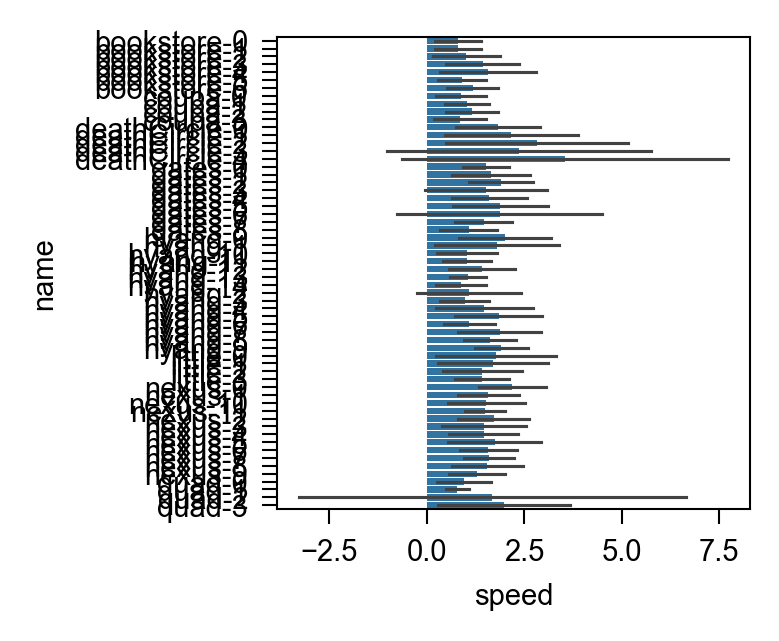

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils.plot import get_fig

df_all = pd.concat([v.assign(name=k) for k, v in speeds.items()], axis=0, ignore_index=True)
fi, fig, axes = get_fig(1, 1, AW=4, AH=4, dpi=300, sharex=True, sharey=True)
sns.barplot(data=df_all[df_all['speed']>0], y='name', x='speed', ci='sd', ax=axes[0])

In [78]:
(df_all['speed']>9).sum()

np.int64(808)

Text(0.5, 1.0, 'hyang-5 trajectories')

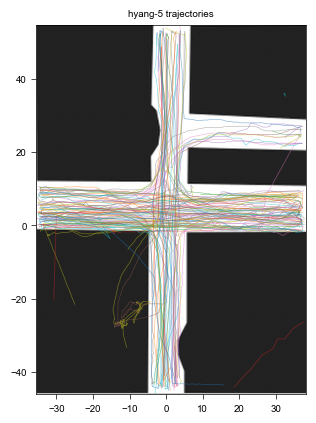

In [60]:
import random

dataset = random.choice(datasets)
df_data = dataset.df_data
map_data = dataset.map_data

plt.imshow(map_data.map, cmap='gray_r', origin='lower', extent=(map_data.xmin, map_data.xmax, map_data.ymin, map_data.ymax))
for id, group in df_data.groupby('id'):
    plt.plot(group['x'], group['y'], alpha=0.5)
plt.title(f"{dataset.name} trajectories")

# Backup

In [15]:
for pid, group in tqdm(df_data.sort_values(['id', 'f']).groupby('id')):
    speed = group[['x', 'y']].diff().pow(2).sum(axis=1).pow(0.5) / group['f'].diff()
    df_data.loc[group.index, 'speed'] = speed

df_data

100%|██████████| 237/237 [00:00<00:00, 674.33it/s]


,id,xmin,ymin,xmax,ymax,f,lost,occluded,generated,type,width,height,x,y,speed
0,0,213,1038,241,1072,10000,1,0,0,vehicle,28,34,227.0,1055.0,NaN
1,0,211,1038,239,1072,10001,1,0,1,vehicle,28,34,225.0,1055.0,2.0
2,0,211,1038,239,1072,10002,1,0,1,vehicle,28,34,225.0,1055.0,0.0
3,0,211,1038,239,1072,10003,1,0,1,vehicle,28,34,225.0,1055.0,0.0
4,0,211,1038,239,1072,10004,1,0,1,vehicle,28,34,225.0,1055.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361124,236,0,995,41,1072,8527,1,0,1,vehicle,41,77,20.5,1033.5,0.0
361125,236,0,995,41,1072,8528,1,0,1,vehicle,41,77,20.5,1033.5,0.0
361126,236,0,995,41,1072,8529,1,0,1,vehicle,41,77,20.5,1033.5,0.0
361127,236,0,995,41,1072,8530,1,0,1,vehicle,41,77,20.5,1033.5,0.0


[]

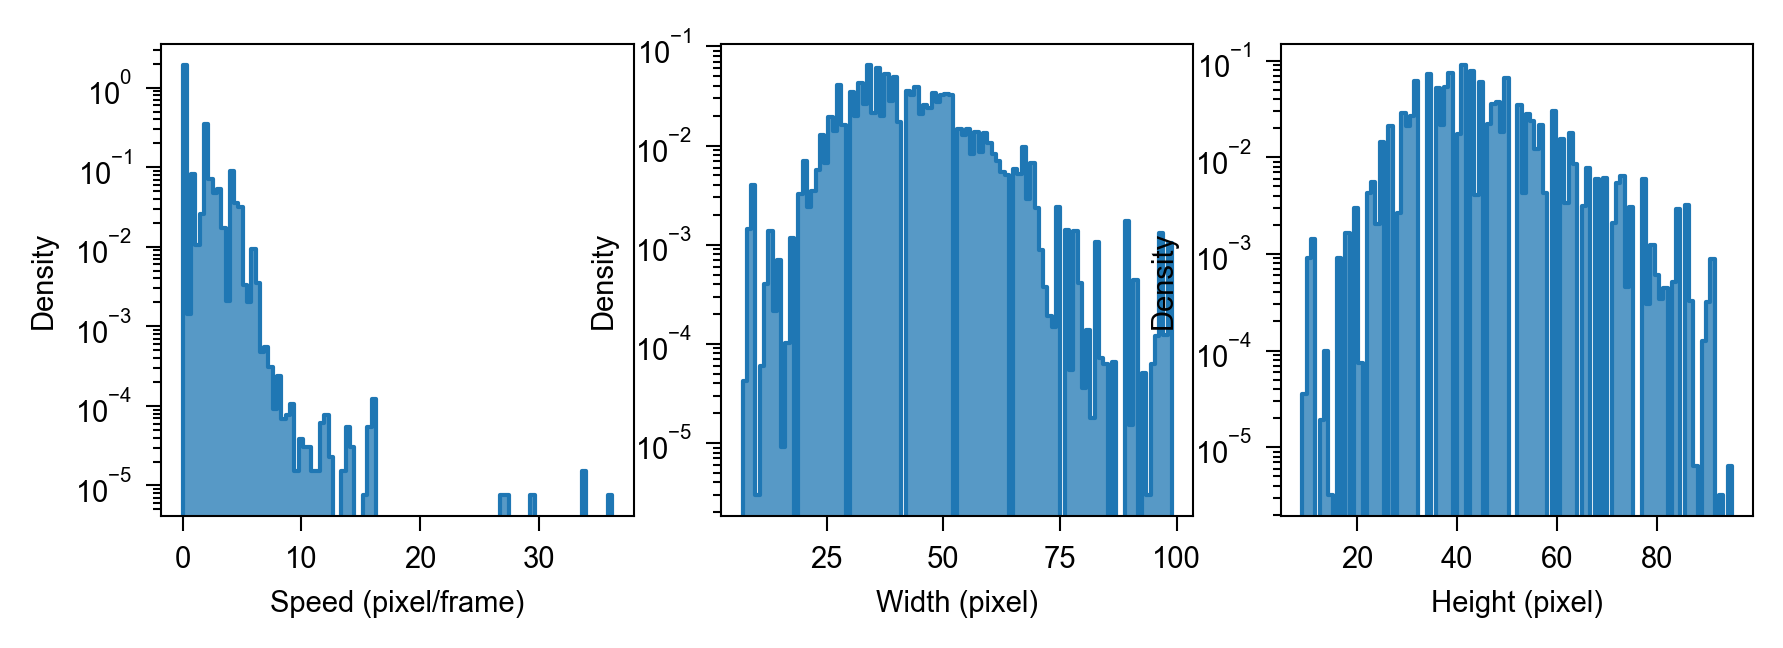

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils.plot import get_fig

fi, fig, axes = get_fig(1, 3, AW=4, AH=4, dpi=300)

sns.histplot(data=df_data, x='speed', bins=100, log_scale=(False, False), stat='density', element='step', ax=axes[0])
axes[0].set_xlabel('Speed (pixel/frame)')
axes[0].semilogy()

sns.histplot(data=df_data, x='width', bins=100, log_scale=(False, False), stat='density', element='step', ax=axes[1])
axes[1].set_xlabel('Width (pixel)')
axes[1].semilogy()

sns.histplot(data=df_data, x='height', bins=100, log_scale=(False, False), stat='density', element='step', ax=axes[2])
axes[2].set_xlabel('Height (pixel)')
axes[2].semilogy()

In [26]:
files = list(sorted(Path('./data/SDD').glob("**/annotations.txt")))

df_data_list = []
for data_path in tqdm(files):
    data_path = Path(data_path)
    df_data = pd.read_csv(
        data_path,
        sep=" ",
        names=[
            "id", "xmin", "ymin", "xmax", "ymax",
            "frame", "lost", "occluded", "generated", "label",
        ],
        # usecols=["id", "xmin", "ymin", "xmax", "ymax", "frame", "label"],
    )
    df_data['width'] = df_data['xmax'] - df_data['xmin']
    df_data['height'] = df_data['ymax'] - df_data['ymin']
    df_data["x"] = (df_data["xmin"] + df_data["xmax"]) / 2
    df_data["y"] = (df_data["ymin"] + df_data["ymax"]) / 2
    df_data = df_data.rename(columns={"frame": "f", "label": "type"})
    df_data['type'] = df_data['type'].replace({
        'Pedestrian': 'pedestrian',
        'Skater': 'vehicle',
        'Biker': 'vehicle',
        'Cart': 'vehicle',
        'Car': 'vehicle',
        'Bus': 'vehicle',
    })
    df_data = df_data[df_data['type'] == 'pedestrian']

    for pid, group in tqdm(df_data.sort_values(['id', 'f']).groupby('id')):
        speed = group[['x', 'y']].diff().pow(2).sum(axis=1).pow(0.5) / group['f'].diff()
        df_data.loc[group.index, 'speed'] = speed

    df_data_list.append(df_data)

100%|██████████| 60/60 [00:18<00:00,  3.23it/s]


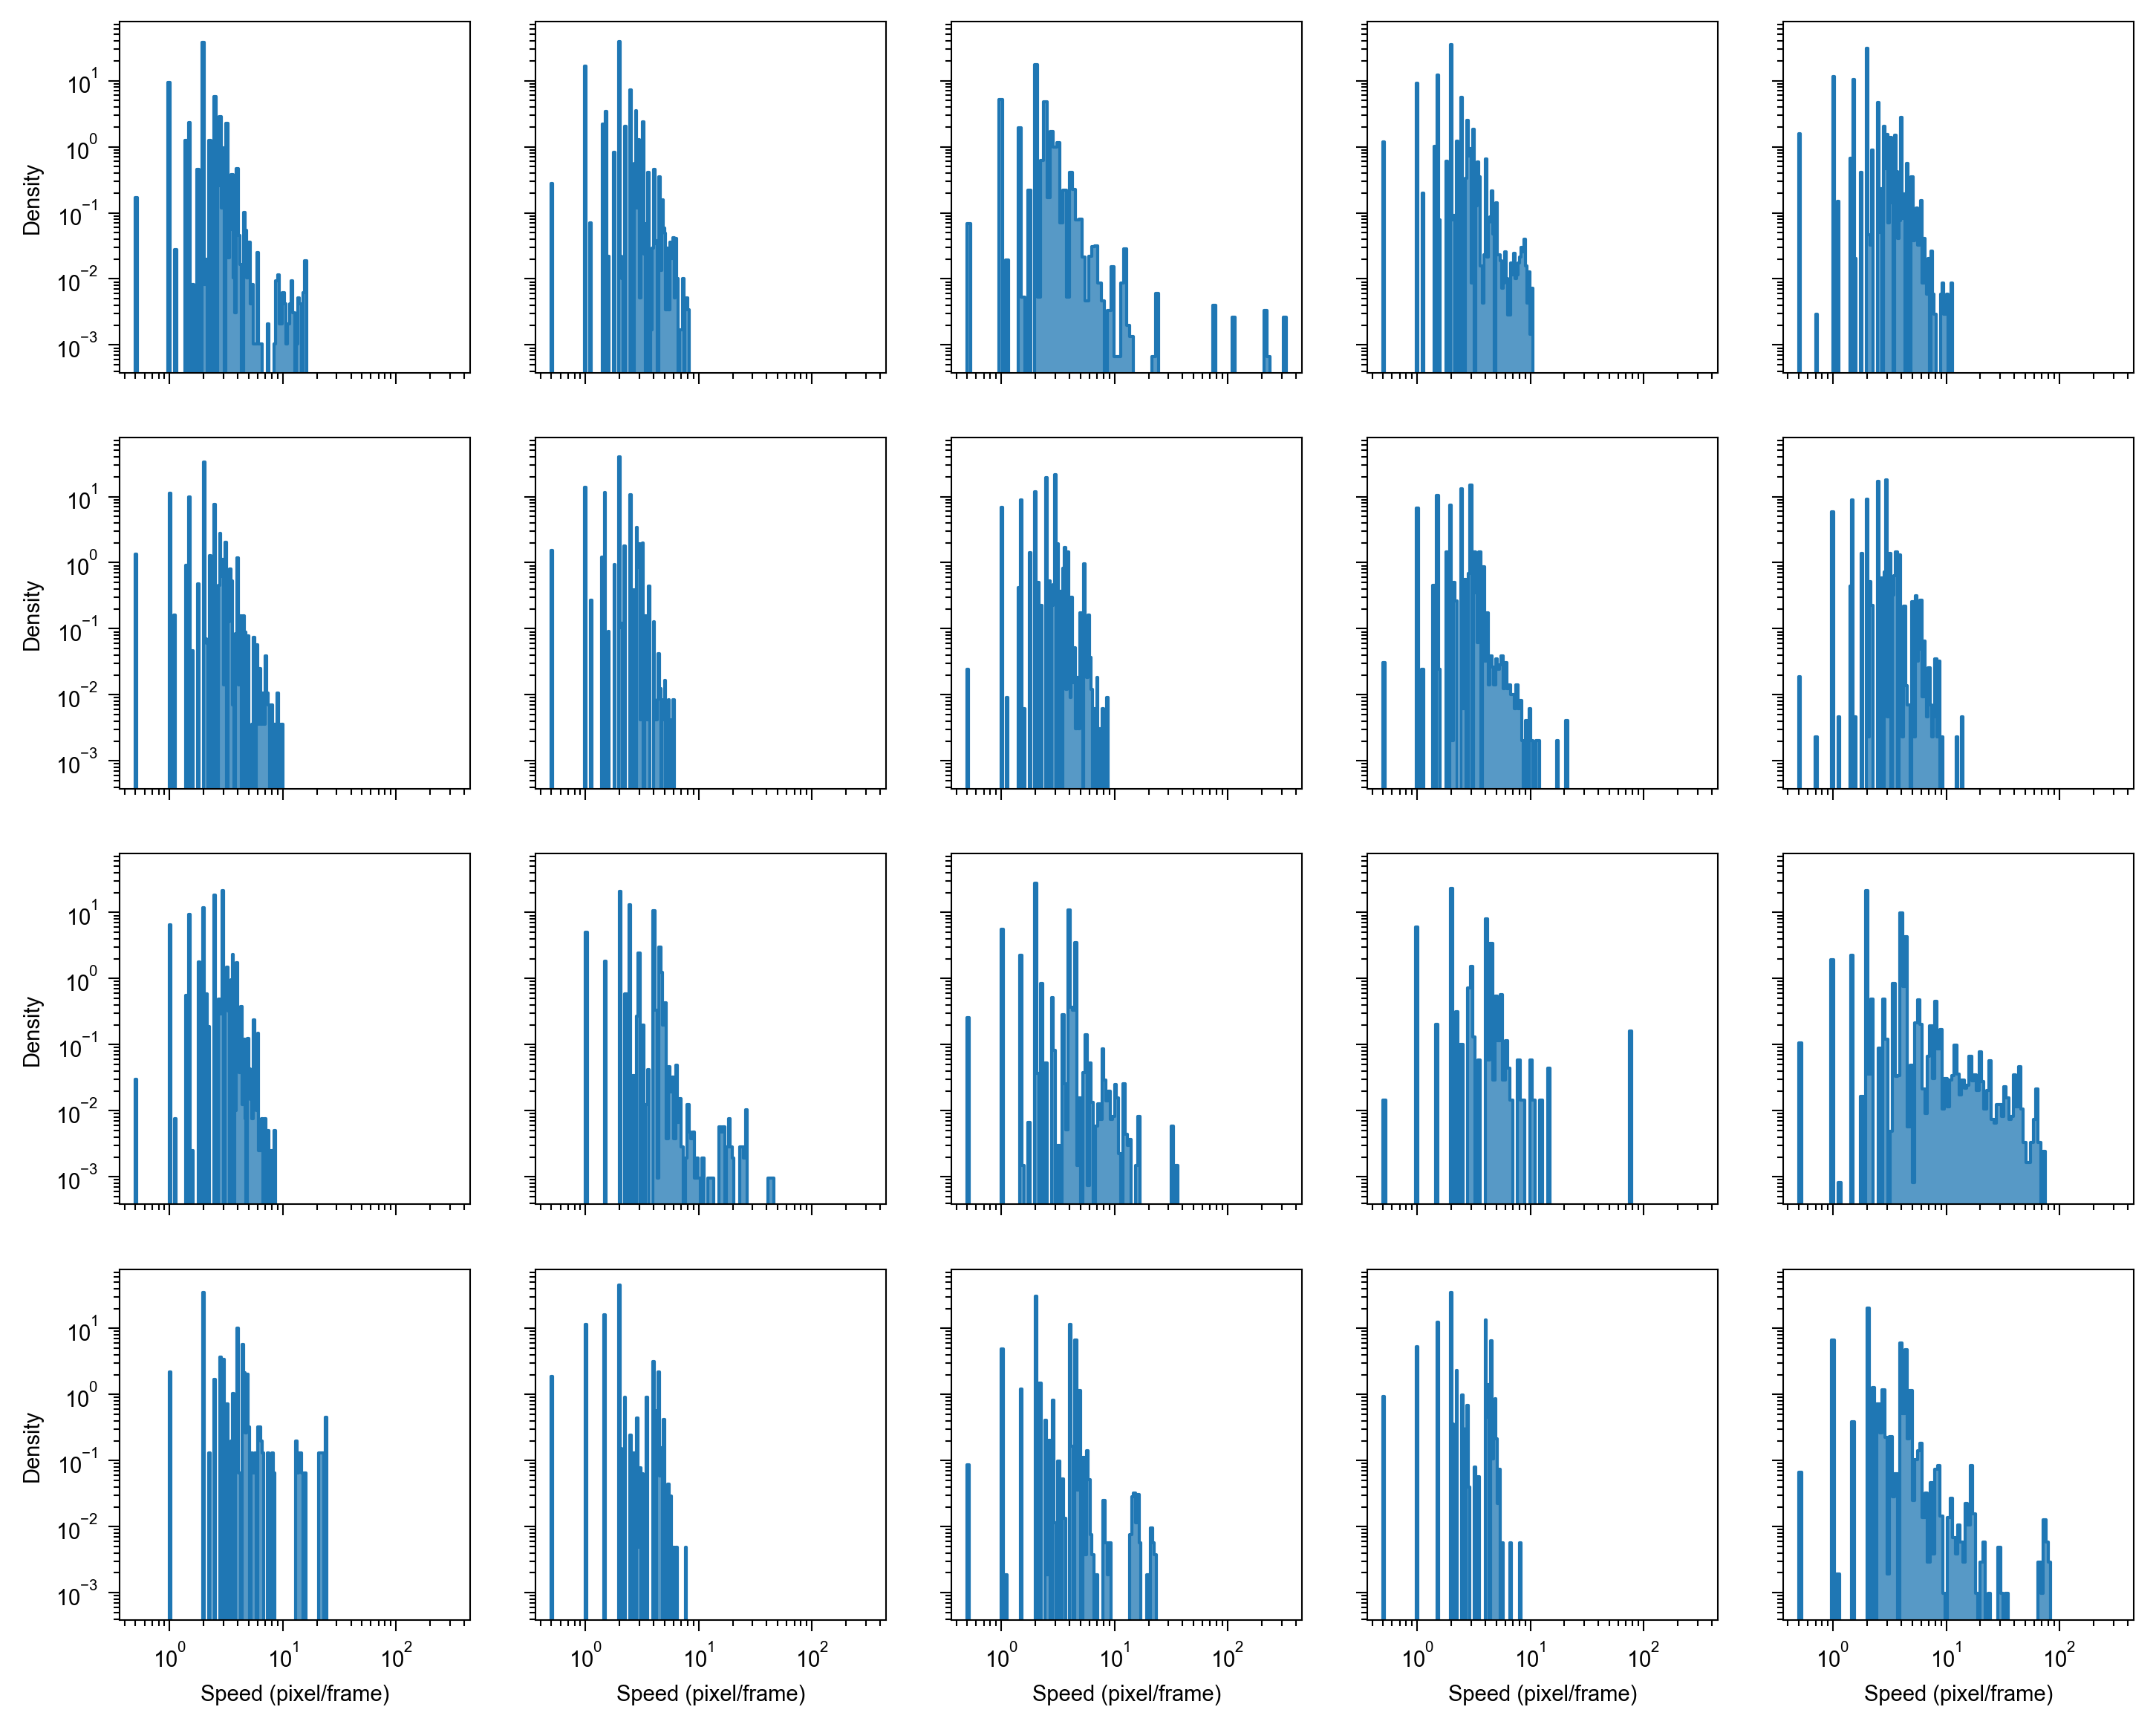

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils.plot import get_fig

fi, fig, axes = get_fig(4, 5, AW=4, AH=4, dpi=300, sharex=True, sharey=True)

for idx, df_data in enumerate(df_data_list[:20]):
    ax = axes[idx]
    sns.histplot(data=df_data[df_data['speed'] > 0], x='speed', bins=100, log_scale=(True, False), stat='density', element='step', ax=ax)
    ax.set_xlabel('Speed (pixel/frame)')
    ax.semilogy()

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils.plot import get_fig

df_list = []
for idx, df_data in enumerate(df_data_list):
    file = files[idx]
    
    print(f"{Path(file).parent.parent.name:20}, {df_data['speed'].mean():.4f}, {df_data['speed'].std():.4f}, {df_data[df_data['speed']>0]['speed'].mean():.4f}, {df_data[df_data['speed']>0]['speed'].std():.4f}")
    df_list.append({
        'name': Path(file).parent.parent.name,
        'mean_speed': df_data['speed'].mean(),
        'std_speed': df_data['speed'].std(),
        'mean_speed2': df_data[df_data['speed']>0]['speed'].mean(),
        'std_speed2': df_data[df_data['speed']>0]['speed'].std(),
    })

bookstore           , 0.5207, 0.9561, 2.0174, 0.7225
bookstore           , 0.4717, 0.9029, 1.9500, 0.6981
bookstore           , 0.6859, 2.4507, 2.1683, 3.9715
bookstore           , 0.6087, 1.0050, 1.9739, 0.7619
bookstore           , 0.6533, 1.0855, 2.0471, 0.9158
bookstore           , 0.5158, 0.9517, 1.9898, 0.7491
bookstore           , 0.4627, 0.8748, 1.9224, 0.6113
coupa               , 0.5745, 1.1152, 2.4505, 0.8414
coupa               , 0.7798, 1.1904, 2.3002, 0.8263
coupa               , 0.8034, 1.2444, 2.4280, 0.8577
coupa               , 0.4059, 0.9642, 2.4392, 0.7919
deathCircle         , 0.5946, 1.2501, 2.6658, 1.2186
deathCircle         , 0.6109, 1.2543, 2.5475, 1.2756
deathCircle         , 1.2334, 3.3301, 2.8797, 4.5992
deathCircle         , 0.9419, 2.4640, 3.3165, 3.6746
deathCircle         , 0.7928, 1.9254, 3.2299, 2.6897
gates               , 0.8588, 1.1147, 1.9483, 0.8342
gates               , 0.8136, 1.4452, 2.7117, 1.3469
gates               , 0.6655, 1.2536, 2.5002, 

<Axes: xlabel='std_speed2', ylabel='Density'>

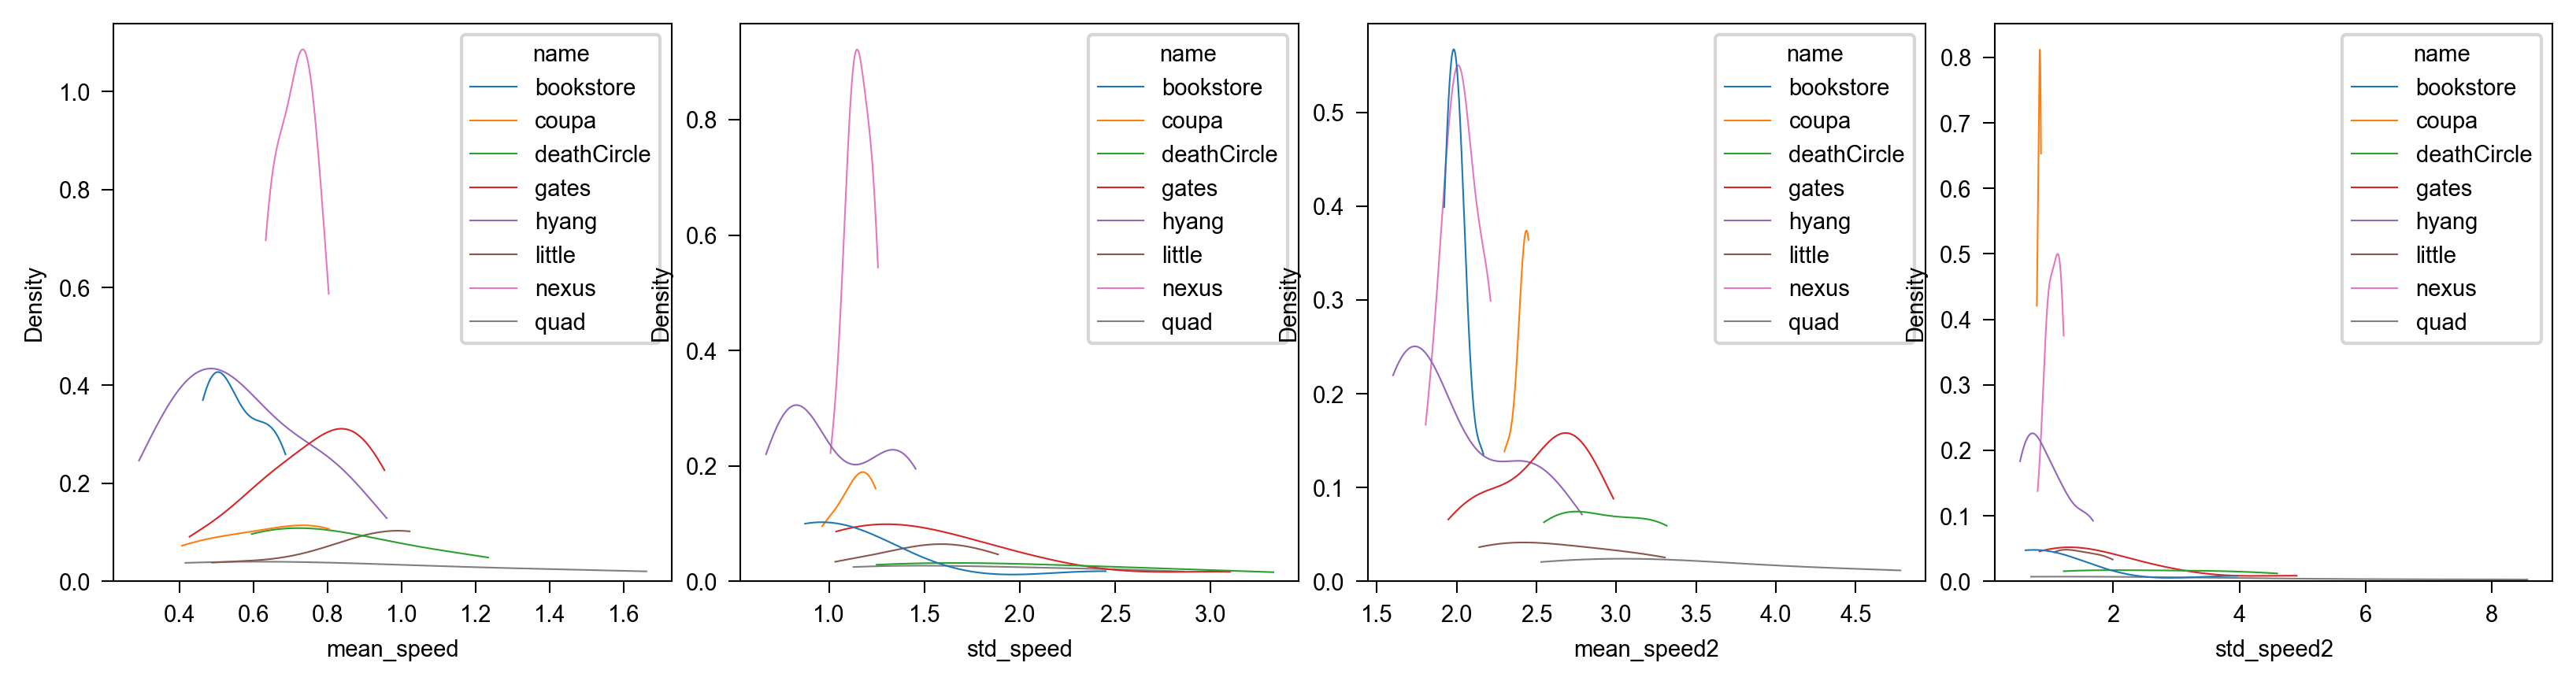

In [64]:
fi, fig, axes = get_fig(1, 4, AW=6, AH=6)
df_summary = pd.DataFrame(df_list)

sns.kdeplot(data=df_summary, hue='name', x='mean_speed', ax=axes[0], cut=0)
sns.kdeplot(data=df_summary, hue='name', x='std_speed', ax=axes[1], cut=0)
sns.kdeplot(data=df_summary, hue='name', x='mean_speed2', ax=axes[2], cut=0)
sns.kdeplot(data=df_summary, hue='name', x='std_speed2', ax=axes[3], cut=0)

bookstore: 2.0 pixel/frame * (36 / 1080) m/pixel * 30 frame/s = 2 m/s
coupa: 2.4 pixel/frame * (30 / 1080) m/pixel * 30 frame/s = 2 m/s
deathCircle: 3.0 pixel/frame * (50/904) m/pixel * 30 frame/s = 5m/s
gate-0: 2.5 pixel/frame * (32/728) m/pixel * 30 frame/s = 1.7m/s
gate-1: 2.5 pixel/frame * (35/780) m/pixel * 30 frame/s = 3.4m/s
gate-2: 2.5 pixel/frame * (43/728) m/pixel * 30 frame/s = 4.4m/s
gate-3: 2.5 pixel/frame * (39/772) m/pixel * 30 frame/s = 3.8m/s
gate-4: 2.5 pixel/frame * (31/784) m/pixel * 30 frame/s = 3.8m/s
gate-5: 2.5 pixel/frame * (40/768) m/pixel * 30 frame/s = 3.8m/s
gate-6: 2.5 pixel/frame * (32/784) m/pixel * 30 frame/s = 3.8m/s
gate-7: 2.5 pixel/frame * (37/728) m/pixel * 30 frame/s = 4.4m/s

In [ ]:
95、57

In [ ]:
2.0 pixel/frame * (25 / 1080) m/pixel * 30 frame/s = 2 m/s

In [34]:
files[2]

PosixPath('data/SDD/annotations/bookstore/video2/annotations.txt')

In [33]:
df_data_list[2].sort_values('width')

,id,xmin,ymin,xmax,ymax,f,lost,occluded,generated,type,width,height,x,y,speed
217758,213,229,1031,231,1034,10000,1,0,0,pedestrian,2,3,230.0,1032.5,NaN
220322,215,154,177,156,179,10000,1,0,0,pedestrian,2,2,155.0,178.0,NaN
134396,126,742,959,744,962,10000,1,0,0,pedestrian,2,3,743.0,960.5,NaN
220328,215,152,173,154,177,10006,1,0,1,pedestrian,2,4,153.0,175.0,1.000000
220325,215,152,175,154,177,10003,1,0,1,pedestrian,2,2,153.0,176.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36050,27,114,121,926,1031,10004,1,0,1,pedestrian,812,910,520.0,576.0,1.802776
36049,27,114,121,928,1034,10003,1,0,1,pedestrian,814,913,521.0,577.5,2.828427
36048,27,114,121,932,1038,10002,1,0,1,pedestrian,818,917,523.0,579.5,1.414214
36047,27,114,121,934,1040,10001,1,0,1,pedestrian,820,919,524.0,580.5,4.609772


In [45]:
df_data[df_data['f'] == 10001]

,id,xmin,ymin,xmax,ymax,f,lost,occluded,generated,type,width,height,x,y,speed
16707,18,84,177,132,215,10001,0,0,1,pedestrian,48,38,108.0,196.0,0.000000
25765,19,75,148,132,191,10001,0,0,1,pedestrian,57,43,103.5,169.5,2.000000
36047,27,114,121,934,1040,10001,1,0,1,pedestrian,820,919,524.0,580.5,4.609772
41271,34,1121,0,1163,29,10001,1,0,1,pedestrian,42,29,1142.0,14.5,0.000000
67175,59,0,395,33,449,10001,1,0,1,pedestrian,33,54,16.5,422.0,0.000000
68739,61,442,989,493,1018,10001,1,0,1,pedestrian,51,29,467.5,1003.5,3.201562
73931,67,156,1025,199,1061,10001,0,1,0,pedestrian,43,36,177.5,1043.0,2.000000
115821,108,298,903,1060,1047,10001,1,0,1,pedestrian,762,144,679.0,975.0,2.236068
125077,116,780,195,823,240,10001,0,0,1,pedestrian,43,45,801.5,217.5,2.000000
126109,117,1129,777,1186,829,10001,0,0,1,pedestrian,57,52,1157.5,803.0,3.201562


(np.float64(-63.0),
 np.float64(1323.0),
 np.float64(-53.800000000000004),
 np.float64(1129.8))

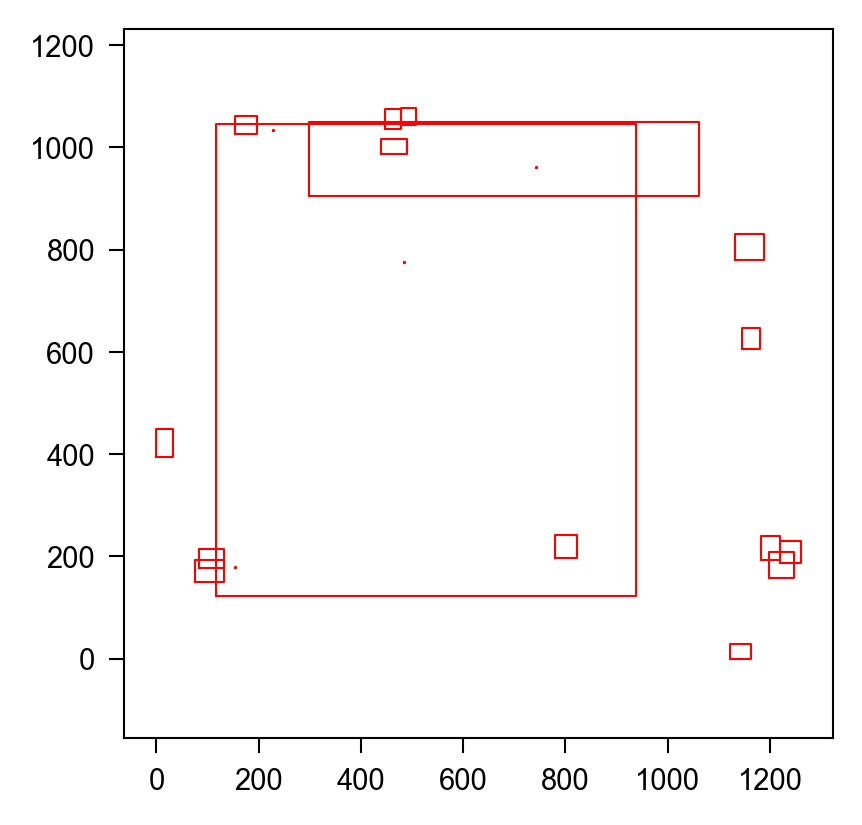

In [44]:
fi, fig, axes = get_fig(1, 1, AW=6, AH=6)

df_data = df_data_list[2]
for idx, row in df_data[df_data['f'] == 10000].iterrows():
    xmin = row['xmin']
    xmax = row['xmax']
    ymin = row['ymin']
    ymax = row['ymax']
    axes[0].plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin], color='r', linewidth=0.5)
    # axes[0].text(xmin, ymin, f"{row['id']}", color='r', fontsize=8)
axes[0].axis('equal')

In [50]:
df_data[df_data['id'] == 108].sort_values('f')

,id,xmin,ymin,xmax,ymax,f,lost,occluded,generated,type,width,height,x,y,speed
115820,108,298,905,1062,1049,10000,1,0,0,pedestrian,764,144,680.0,977.0,NaN
115821,108,298,903,1060,1047,10001,1,0,1,pedestrian,762,144,679.0,975.0,2.236068
115822,108,300,903,1060,1047,10002,1,0,1,pedestrian,760,144,680.0,975.0,1.000000
115823,108,300,903,1060,1047,10003,1,0,1,pedestrian,760,144,680.0,975.0,0.000000
115824,108,302,901,1060,1045,10004,1,0,1,pedestrian,758,144,681.0,973.0,2.236068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117347,108,1390,76,1418,128,11527,1,0,1,pedestrian,28,52,1404.0,102.0,0.000000
117348,108,1390,76,1418,128,11528,1,0,1,pedestrian,28,52,1404.0,102.0,0.000000
117349,108,1390,76,1418,128,11529,1,0,1,pedestrian,28,52,1404.0,102.0,0.000000
117350,108,1390,76,1418,128,11530,1,0,1,pedestrian,28,52,1404.0,102.0,0.000000


(np.float64(242.0), np.float64(1474.0), np.float64(25.25), np.float64(1097.75))

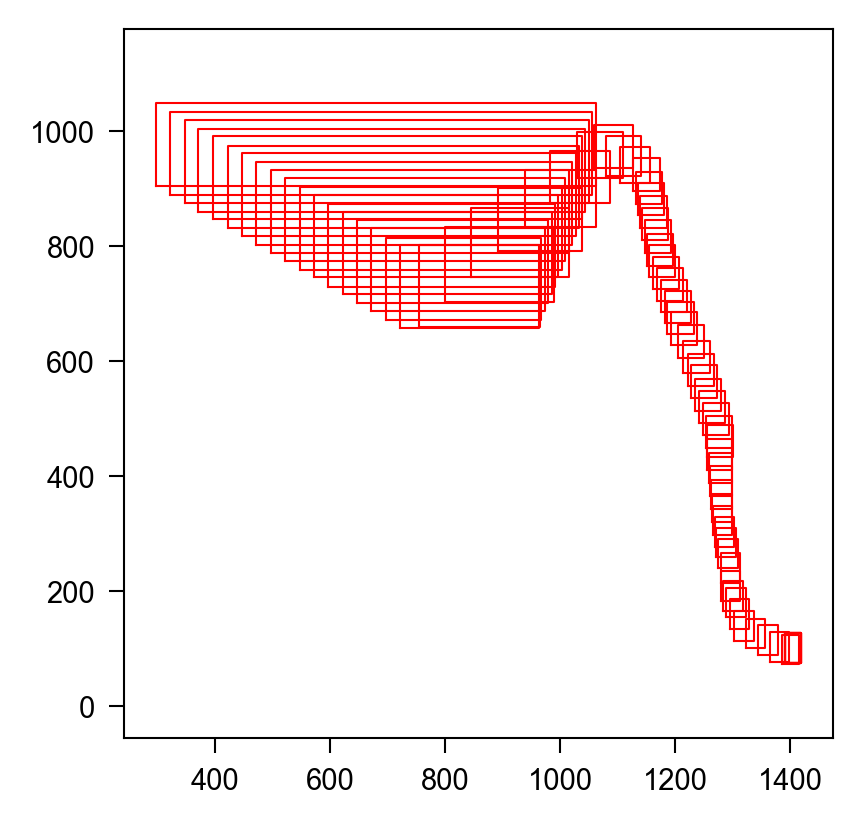

In [49]:
fi, fig, axes = get_fig(1, 1, AW=6, AH=6)

df_data = df_data_list[2]
for idx, row in df_data[df_data['id'] == 108][::20].iterrows():
    xmin = row['xmin']
    xmax = row['xmax']
    ymin = row['ymin']
    ymax = row['ymax']
    axes[0].plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin], color='r', linewidth=0.5)
    # axes[0].text(xmin, ymin, f"{row['id']}", color='r', fontsize=8)
axes[0].axis('equal')

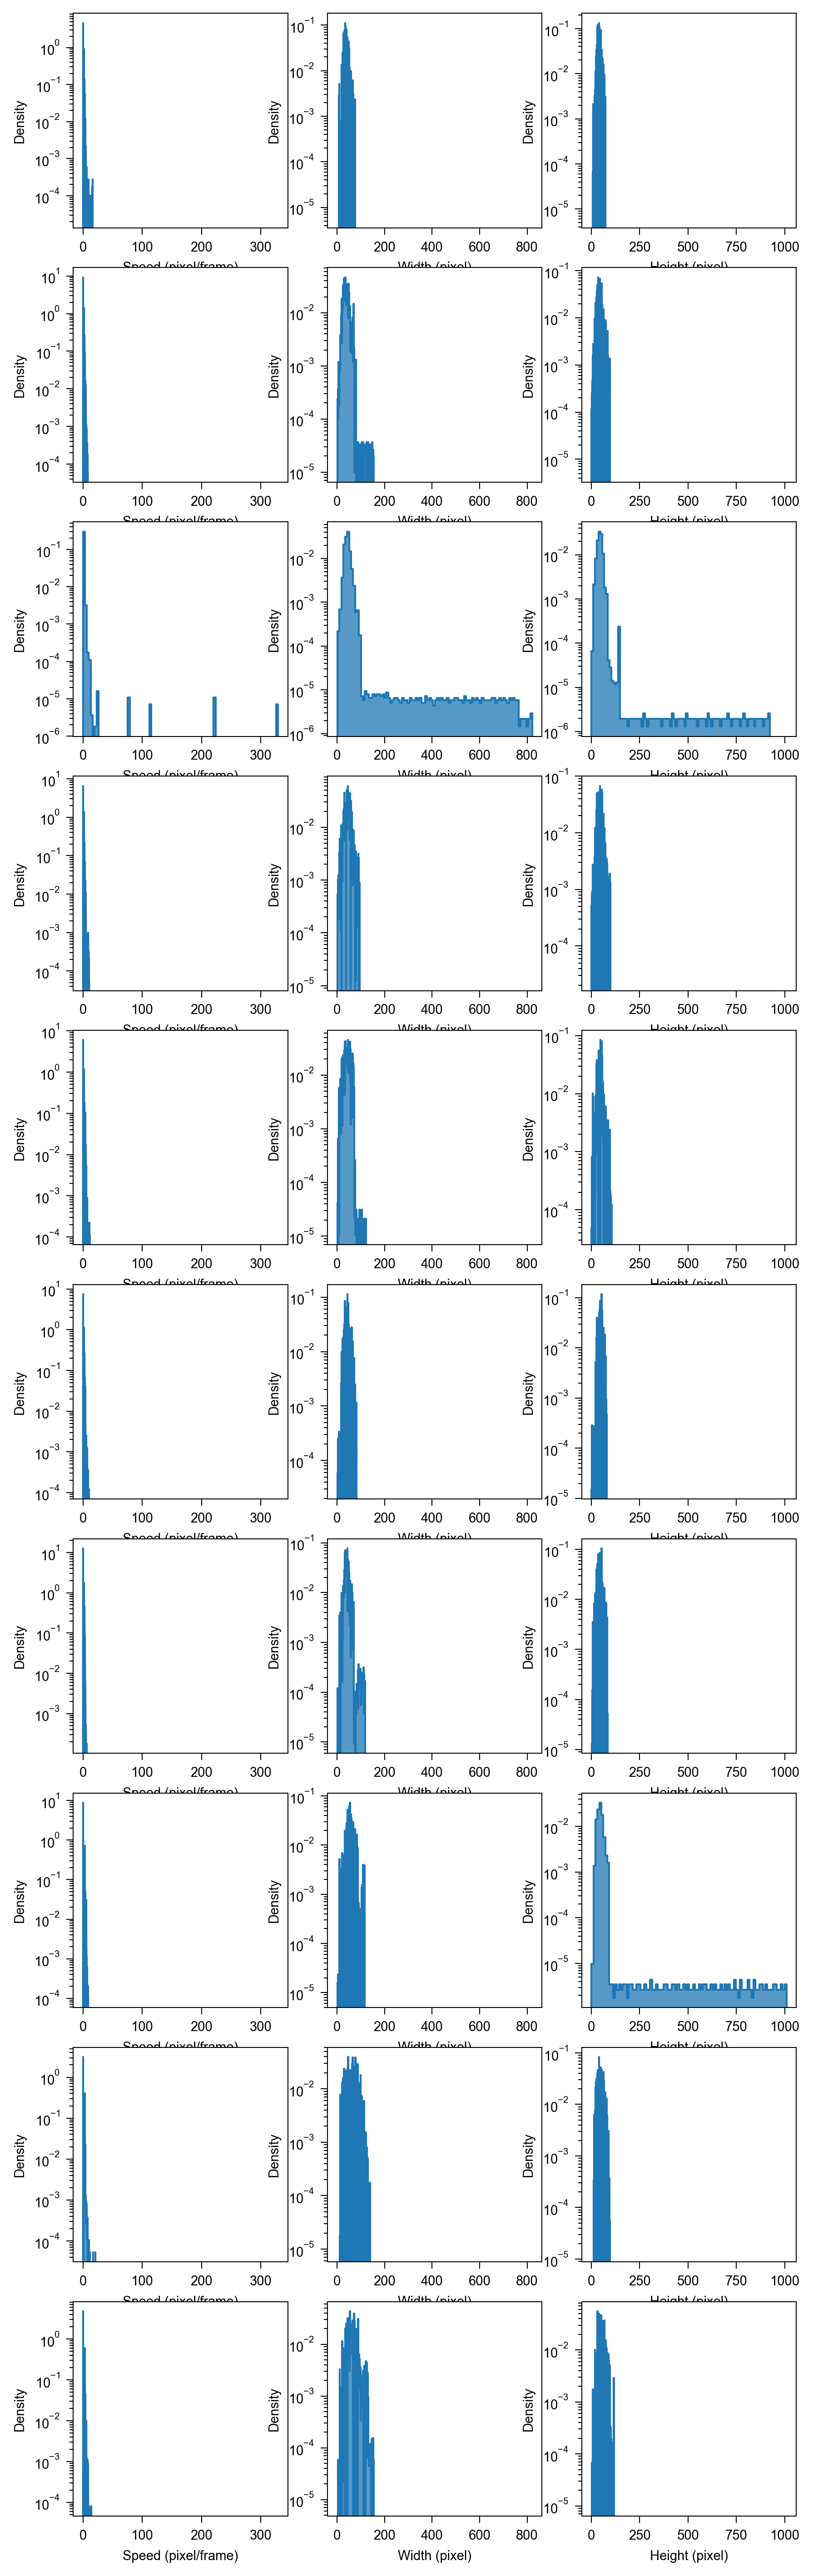

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils.plot import get_fig

fi, fig, axes = get_fig(10, 3, AW=4, AH=4, dpi=300)
axes = axes.reshape(10, 3)

for idx, df_data in enumerate(df_data_list[:10]):
    ax = axes[idx, 0]
    if idx > 0: ax.sharex(axes[0, 0])
    sns.histplot(data=df_data, x='speed', bins=100, log_scale=(False, False), stat='density', element='step', ax=ax)
    ax.set_xlabel('Speed (pixel/frame)')
    ax.semilogy()

    ax = axes[idx, 1]
    if idx > 0: ax.sharex(axes[0, 1])
    sns.histplot(data=df_data, x='width', bins=100, log_scale=(False, False), stat='density', element='step', ax=ax)
    ax.set_xlabel('Width (pixel)')
    ax.semilogy()

    ax = axes[idx, 2]
    if idx > 0: ax.sharex(axes[0, 2])
    sns.histplot(data=df_data, x='height', bins=100, log_scale=(False, False), stat='density', element='step', ax=ax)
    ax.set_xlabel('Height (pixel)')
    ax.semilogy()